In [56]:
import cv2
import easyocr
import imutils
from matplotlib import pyplot as plt
import numpy as np

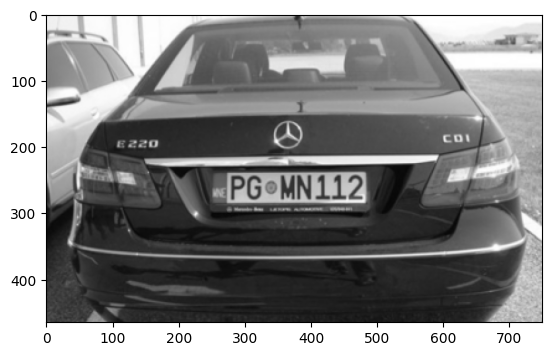

In [57]:
# resize and grayscale
def resize(img: np.ndarray, target_w: int = 750) -> np.ndarray:
    aspect   = img.shape[0] / img.shape[1]
    target_h = int(target_w * aspect)
    return cv2.resize(img, (target_w, target_h), interpolation=cv2.INTER_AREA)

PATH = '/kaggle/input/datasets/andrewmvd/car-plate-detection/images/Cars1.png'
img = cv2.imread(PATH)
img = resize(img)

gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
plt.imshow(cv2.cvtColor(gray, cv2.COLOR_BGR2RGB))

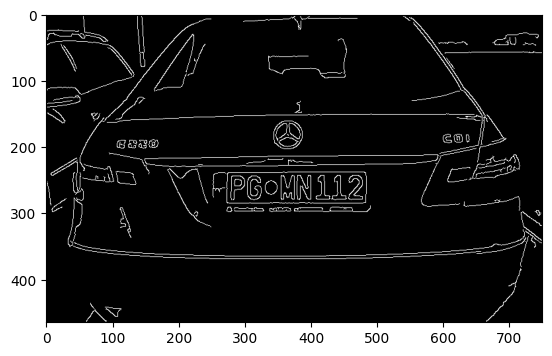

In [58]:

# removing noise and detecting edges
blurred_image = cv2.GaussianBlur(gray, (5, 5), 0)

lower_thresh = 50
upper_thresh = 180
edges = cv2.Canny(blurred_image, lower_thresh, upper_thresh)

plt.imshow(edges, cmap='gray')

In [59]:
# corner detection 

keypoints = cv2.findContours(edges.copy(), cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)
contours = imutils.grab_contours(keypoints)
contours = sorted(contours, key=cv2.contourArea, reverse=True)[:10]

corners = None
for contour in contours:
    approx = cv2.approxPolyDP(contour, 10, True)
    if len(approx) == 4:
        corners = approx
        break



print(corners)

[[[273 241]]

 [[274 285]]

 [[483 284]]

 [[481 238]]]


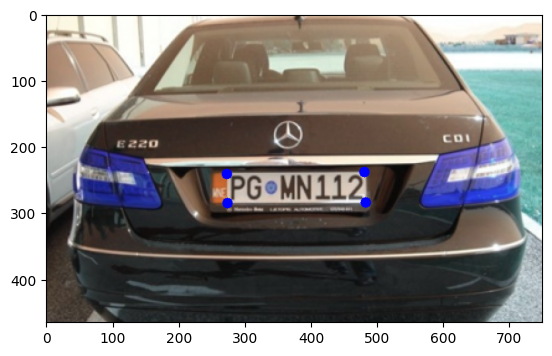

In [60]:
#Annotating points
img_cpy = img.copy()
for c in corners:
    x, y = c.ravel()
    cv2.circle(img_cpy, (x, y), 8, (0, 0, 255), -1)

plt.imshow(img_cpy)

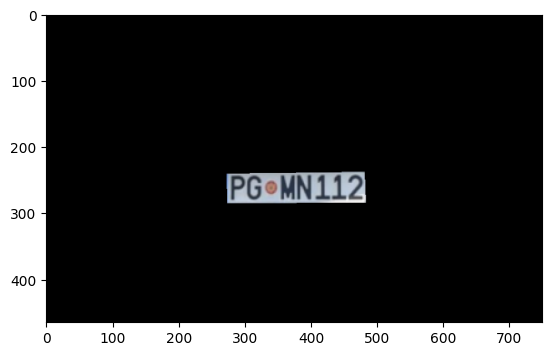

In [61]:
# mask all pixels except for corner regions
mask = np.zeros(gray.shape, np.uint8)
new_image = cv2.drawContours(mask, [corners], 0,255, -1)
new_image = cv2.bitwise_and(img, img, mask=mask)

plt.imshow(cv2.cvtColor(new_image, cv2.COLOR_BGR2RGB))

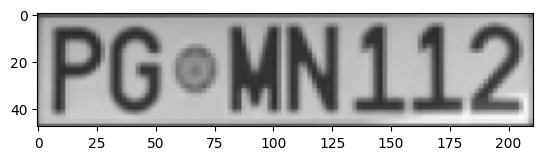

In [62]:

(x,y) = np.where(mask==255)
(x1, y1) = (np.min(x), np.min(y))
(x2, y2) = (np.max(x), np.max(y))
cropped_image = gray[x1:x2+1, y1:y2+1]

plt.imshow(cv2.cvtColor(cropped_image, cv2.COLOR_BGR2RGB))

In [63]:
# Using OCR
reader = easyocr.Reader(['en'])
result = reader.readtext(cropped_image)

print(result)

Neither CUDA nor MPS are available - defaulting to CPU. Note: This module is much faster with a GPU.


[([[0, 0], [211, 0], [211, 48], [0, 48]], 'PGoMN112', np.float64(0.7586674379027447))]


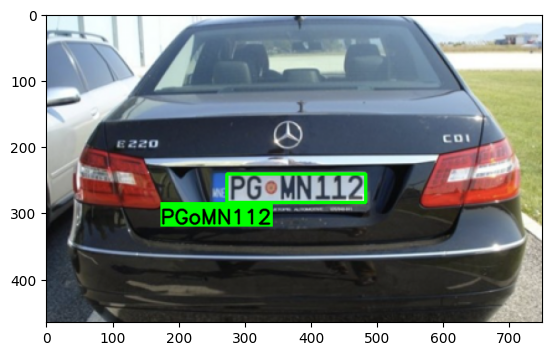

In [64]:
text = result[0][-2]
bottom_y = approx[2][0][1]
left_x = approx[0][0][0] - 100

font = cv2.FONT_HERSHEY_SIMPLEX
font_scale = 1
thickness = 2
(text_w, text_h), baseline = cv2.getTextSize(text, font, font_scale, thickness)

text_org = (left_x, bottom_y + text_h + baseline)

cv2.rectangle(img,
              (left_x, bottom_y),
              (left_x + text_w, bottom_y + text_h + baseline + 4),
              (0, 255, 0), cv2.FILLED)

res = cv2.putText(img, text=text, org=text_org, fontFace=font,
                  fontScale=font_scale, color=(0, 0, 0), thickness=thickness,
                  lineType=cv2.LINE_AA)

res = cv2.rectangle(img, tuple(approx[0][0]), tuple(approx[2][0]), (0, 255, 0), 3)
plt.imshow(cv2.cvtColor(res, cv2.COLOR_BGR2RGB))